# Optimisation for Volume Rendering of 3D Datacubes
Group 15

- NG, Cheuk Nam (cnng@kth.se)
- Wong, Chun Him (chwon@kth.se)

Git Repository:
[https://github.com/anson-ryea/dd2358-work/tree/main/project](https://github.com/anson-ryea/dd2358-work/tree/main/project)

# 1. Problem Statement

In this project, the characteristics of a ray-casting volume rendering algorithm implemented in Python by Philip Mocz were first profiled and analysed, then optimised through 3 different methods including parallelisation, pre-compilation and offloading to GPU calculations.

The original code implements ray-casting volume rendering of three-dimensional scalar field data, originally developed to visualise outputs from a Schrödinger–Poisson simulation. The render_original function begins by loading a density datacube from an HDF5 file using h5py, then constructs a uniform Cartesian coordinate grid spanning the datacube dimensions. For each of Nangles viewing angles, the camera grid, a cubic mesh of N³ query points, is rotated about the x-axis by incrementing the angle uniformly from $0$ to $π/2$. The rotated query coordinates are passed to scipy.interpolate.interpn, which performs trilinear interpolation of the datacube onto the camera grid. Volume rendering is then performed by iterating through depth slices of the interpolated grid. For each slice, the transferFunction applies Gaussian-weighted colour and opacity mappings (RGBA) as a function of the log-density value, compositing each slice onto the accumulating image via front-to-back alpha blending. The final image is clipped to $[0, 1]$ and saved as a PNG. After all angles are rendered, a simple mean-projection image is additionally saved using a viridis colormap for reference comparison.

# 2. Extensions and Imports

In [1]:
import time
import numpy as np
import h5py
import os
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

In [9]:
%load_ext line_profiler
%load_ext memory_profiler

# 3. Original Code

The original `main()` has been renamed to `render_original()`. `path`, `N` and `Nangles` are also added as arguments for the path to the datacube, the camera grid size and the number of viewing angles, respectively. The print line for rendering progress has been commented out to avoid cluttering the profiling results. The original datacube file is named `datacube_original.hdf5`.

In [2]:
%%file renderer_original.py
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interpn

"""
Create Your Own Volume Rendering (With Python)
Philip Mocz (2020) Princeton University, @PMocz

Simulate the Schrodinger-Poisson system with the Spectral method
"""

def transferFunction(x):
    r = (
            1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    g = (
            1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 1.0 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    b = (
            0.1 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 1.0 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    a = (
            0.6 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 0.01 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )

    return r, g, b, a

def render_original(path, N, Nangles):
    """Volume Rendering"""

    # Load Datacube
    f = h5.File(path, "r")
    datacube = np.array(f["density"])

    # Datacube Grid
    Nx, Ny, Nz = datacube.shape
    x = np.linspace(-Nx / 2, Nx / 2, Nx)
    y = np.linspace(-Ny / 2, Ny / 2, Ny)
    z = np.linspace(-Nz / 2, Nz / 2, Nz)
    points = (x, y, z)

    # Do Volume Rendering at Different Viewing Angles
    for i in range(Nangles):
        # print("Rendering Scene " + str(i + 1) + " of " + str(Nangles) + ".\n")

        # Camera Grid / Query Points -- rotate camera view
        angle = np.pi / 2 * i / Nangles
        c = np.linspace(-N / 2, N / 2, N)
        qx, qy, qz = np.meshgrid(c, c, c)
        qxR = qx
        qyR = qy * np.cos(angle) - qz * np.sin(angle)
        qzR = qy * np.sin(angle) + qz * np.cos(angle)
        qi = np.array([qxR.ravel(), qyR.ravel(), qzR.ravel()]).T

        # Interpolate onto Camera Grid
        camera_grid = interpn(points, datacube, qi, method="linear").reshape((N, N, N))

        # Do Volume Rendering
        image = np.zeros((camera_grid.shape[1], camera_grid.shape[2], 3))

        for dataslice in camera_grid:
            r, g, b, a = transferFunction(np.log(dataslice))
            image[:, :, 0] = a * r + (1 - a) * image[:, :, 0]
            image[:, :, 1] = a * g + (1 - a) * image[:, :, 1]
            image[:, :, 2] = a * b + (1 - a) * image[:, :, 2]

        image = np.clip(image, 0.0, 1.0)

        # Plot Volume Rendering
        plt.figure(figsize=(4, 4), dpi=80)

        plt.imshow(image)
        plt.axis("off")

        # Save figure
        plt.savefig(
            "img_out/volumerender" + str(i) + ".png", dpi=240, bbox_inches="tight", pad_inches=0
        )
        plt.clf()
        plt.close('all')

    # Plot Simple Projection -- for Comparison
    plt.figure(figsize=(4, 4), dpi=80)

    plt.imshow(np.log(np.mean(datacube, 0)), cmap="viridis")
    plt.clim(-5, 5)
    plt.axis("off")

    # Save figure
    plt.savefig("img_out/projection.png", dpi=240, bbox_inches="tight", pad_inches=0)
    plt.close()

    return 0

Overwriting renderer_original.py


In [3]:
from renderer_original import render_original, transferFunction

# 4. Profiling the Original Source Code

## 4.1 Profiling the functions

In [ ]:
%%prun -s cumulative -l 10 -T prun_out/prun_original
render_original("datacube/datacube_original.hdf5", 180, 10) # N=180, Nangles=10 from the original code

 
*** Profile printout saved to text file 'prun_out/prun_original'.


In [ ]:
print(open('prun_out/prun_original', 'r').read())

         428206 function calls (420265 primitive calls) in 7.585 seconds

   Ordered by: cumulative time
   List reduced from 1456 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      9/1    0.000    0.000    7.581    7.581 {built-in method builtins.exec}
        1    0.460    0.460    7.581    7.581 renderer_original.py:37(render_original)
       10    0.058    0.006    4.361    0.436 _rgi.py:645(interpn)
       10    0.000    0.000    4.297    0.430 _rgi.py:375(__call__)
       10    2.894    0.289    2.894    0.289 _rgi.py:520(_evaluate_linear)
     1800    2.098    0.001    2.098    0.001 renderer_original.py:13(transferFunction)
       10    1.435    0.143    1.461    0.146 _rgi.py:632(_find_indices)
        3    0.006    0.002    0.249    0.083 base_events.py:1966(_run_once)
        3    0.000    0.000    0.243    0.081 selectors.py:540(select)
       11    0.000    0.000    0.221    0.020 pyplot.py:1245(savefig)


## 4.2 Line-by-line profiling

### 4.2.1 `render_original()`

In [ ]:
%lprun -T prun_out/lprun_render_original -f render_original render_original("datacube/datacube_original.hdf5", 180, 10) # N=180, Nangles=10 from the original code
print(open('prun_out/lprun_render_original', 'r').read())


*** Profile printout saved to text file 'prun_out/lprun_render_original'. 
Timer unit: 1e-09 s

Total time: 7.76715 s
File: /Users/anson/Documents/dd2358-work/project/renderer_original.py
Function: render_original at line 37

Line #      Hits         Time  Per Hit   % Time  Line Contents
    37                                           def render_original(path, N, Nangles):
    38                                               """Volume Rendering"""
    39                                           
    40                                               # Load Datacube
    41         1    1071000.0 1.07e+06      0.0      f = h5.File(path, "r")
    42         1    6779000.0 6.78e+06      0.1      datacube = np.array(f["density"])
    43                                           
    44                                               # Datacube Grid
    45         1       3000.0   3000.0      0.0      Nx, Ny, Nz = datacube.shape
    46         1      89000.0  89000.0      0.0      x = np.lins

### 4.2.2 `transferFunction()`

In [ ]:
%lprun -T prun_out/lprun_transfer_original -f transferFunction render_original("datacube/datacube_original.hdf5", 180, 10) # N=180, Nangles=10 from the original code
print(open('prun_out/lprun_transfer_original', 'r').read())


*** Profile printout saved to text file 'prun_out/lprun_transfer_original'. 
Timer unit: 1e-09 s

Total time: 2.15272 s
File: /Users/anson/Documents/dd2358-work/project/renderer_original.py
Function: transferFunction at line 13

Line #      Hits         Time  Per Hit   % Time  Line Contents
    13                                           def transferFunction(x):
    14      1800     371000.0    206.1      0.0      r = (
    15      5400  198760000.0  36807.4      9.2              1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
    16      1800  170454000.0  94696.7      7.9              + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
    17      1800  168859000.0  93810.6      7.8              + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    18                                               )
    19      1800     365000.0    202.8      0.0      g = (
    20      5400  197596000.0  36591.9      9.2              1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
    21      1800  169709000.0  94282.8      7.9            

## 4.3 Memory profiling

### `render_original()`

In [ ]:
%mprun -T prun_out/mprun_render_original -f render_original render_original("datacube/datacube_original.hdf5", 180, 10) # N=180, Nangles=10 from the original code
print(open('prun_out/mprun_render_original', 'r').read())



*** Profile printout saved to text file prun_out/mprun_render_original. 
Filename: /Users/anson/Documents/dd2358-work/project/renderer_original.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    37   1449.9 MiB   1449.9 MiB           1   def render_original(path, N, Nangles):
    38                                             """Volume Rendering"""
    39                                         
    40                                             # Load Datacube
    41   1449.9 MiB      0.0 MiB           1       f = h5.File(path, "r")
    42   1449.9 MiB      0.0 MiB           1       datacube = np.array(f["density"])
    43                                         
    44                                             # Datacube Grid
    45   1449.9 MiB      0.0 MiB           1       Nx, Ny, Nz = datacube.shape
    46   1449.9 MiB      0.0 MiB           1       x = np.linspace(-Nx / 2, Nx / 2, Nx)
    47   1449.9 MiB      0.0 MiB           1       y = np.linspace(-Ny /

### `transferFunction()`

In [ ]:
%mprun -T prun_out/mprun_transfer_original -f transferFunction render_original("datacube/datacube_original.hdf5", 180, 10) # N=180, Nangles=10 from the original code
print(open('prun_out/mprun_transfer_original', 'r').read())



*** Profile printout saved to text file prun_out/mprun_transfer_original. 
Filename: /Users/anson/Documents/dd2358-work/project/renderer_original.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    13   1453.7 MiB   1453.7 MiB        1800   def transferFunction(x):
    14   1453.7 MiB      0.0 MiB        1800       r = (
    15   1453.7 MiB      0.0 MiB        5400               1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
    16   1453.7 MiB      0.0 MiB        1800               + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
    17   1453.7 MiB      0.0 MiB        1800               + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    18                                             )
    19   1453.7 MiB      0.0 MiB        1800       g = (
    20   1453.7 MiB      0.0 MiB        5400               1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
    21   1453.7 MiB      0.0 MiB        1800               + 1.0 * np.exp(-((x - 3.0) ** 2) / 0.1)
    22   1453.7 MiB      0.0 MiB        1800           

# 5. Investigating different factors affecting the performance

## 5.1 Generating datacubes with different sizes

In [6]:
def generate_datacube(size=180, seed=42, suffix=""):
    filename = "datacube_" + str(size) + ("_" if len(suffix) > 0 else "") + suffix + ".hdf5"
    if os.path.exists(filename):
        os.remove(filename)

    print(f"Generating sphere in void dataset of size {size}^3 slice-by-slice with seed {seed}")

    rng = np.random.default_rng(seed)

    center = size / 2.0
    radius = size / 4.0
    sigma = radius / 2.0

    # Scale factor for the object (to hit log(x)~9.0 peak)
    object_intensity = 10000.0

    # Background value (to hit log(x)~-3.0 or lower where alpha is low)
    background_density = 0.1

    with h5py.File("datacube/generated/" + filename, 'w') as f:
        dset = f.create_dataset("density", (size, size, size), dtype='float32')

        y = np.arange(size, dtype='float32')
        x = np.arange(size, dtype='float32')
        Y, X = np.meshgrid(y, x, indexing='ij')

        dist_sq_slice = (Y - center)**2 + (X - center)**2

        for z in range(size):
            # Z distance
            dist_sq_z = (z - center)**2
            total_dist_sq = dist_sq_slice + dist_sq_z

            sphere_signal = np.exp(-total_dist_sq / (2 * sigma**2))

            noise = rng.random((size, size), dtype='float32') * sphere_signal * 0.5

            slice_density = background_density + (sphere_signal + noise) * object_intensity

            dset[z, :, :] = slice_density

            if z % 50 == 0:
                print(f"Processed slice {z}/{size}")

    print(f"Successfully created {filename} with shape ({size}, {size}, {size})")
    return filename

In [ ]:
for size in [200, 300, 400, 500, 600, 700, 800, 900, 1000]:
    generate_datacube(size=size)

## 5.2 Variable Datacube Sizes

The following code runs the `render_original` function on datacubes of varying sizes, measuring the execution time for each size. The following parameters are used:

- Datacube size: $[300-1000]$ with a step of $100$
- Camera grid size (N): $180$ (same as the original code)
- Number of viewing angles (Nangles): $10$ (same as the original code)
- Number of runs: $5$ (to get an average and standard deviation for each size)

### Benchmark Helper Function

In [2]:
def run_size_benchmark(render_func, sizes=range(300, 1100, 100), N=180, Nangles=10, num_runs=5):
    files_to_test = [("Original", "datacube/datacube_original.hdf5")]
    for size in sizes:
        files_to_test.append((str(size), f"datacube/generated/datacube_{size}.hdf5"))

    # 1. Setup Original Markdown Table Structure
    md_output = "| Datacube Size | Average Time (s) | Std Dev (s) |\n| :--- | :--- | :--- |\n"

    results = []

    # 2. Run Benchmarks
    for label, filename in files_to_test:
        times = []
        error_occurred = False
        print(f"Running benchmark for: {label}...", end="\r")

        for _ in range(num_runs):
            try:
                start_time = time.time()
                render_func(filename, N, Nangles)
                times.append(time.time() - start_time)
            except Exception as e:
                md_output += f"| {label} | Error: {e} | - |\n"
                error_occurred = True
                break

        if not error_occurred and times:
            avg_time = np.mean(times)
            std_dev = np.std(times)

            # Add to Markdown Table (Original Format)
            md_output += f"| {label} | {avg_time:.4f} | {std_dev:.4f} |\n"

            # Save stats for the Chart
            results.append({
                "label": label,
                "mean": avg_time,
                "std": std_dev,
                "min": np.min(times),
                "max": np.max(times)
            })

    print("Benchmark complete.                               ") # Clear progress line

    # 3. Display Original Markdown Table
    display(Markdown(md_output))

    # 4. Display Whiskey Mox Chart
    if results:
        plt.figure(figsize=(10, 6), dpi=100)

        labels = [r["label"] for r in results]
        x_pos = np.arange(len(labels))

        for i, res in enumerate(results):
            # Whiskers (Min to Max) - Black lines
            plt.vlines(x_pos[i], res["min"], res["max"], color='black', linewidth=1.5, zorder=1)
            plt.hlines([res["min"], res["max"]], x_pos[i]-0.15, x_pos[i]+0.15, color='black', linewidth=1.5, zorder=1)

            # Box (Mean ± Std Dev) - Blue Box
            rect_height = 2 * res["std"]
            rect_bottom = res["mean"] - res["std"]
            plt.gca().add_patch(Rectangle(
                (x_pos[i]-0.25, rect_bottom), 0.5, rect_height,
                facecolor='skyblue', alpha=0.6, edgecolor='blue', zorder=2
            ))

            # Mean - Red Dot
            plt.plot(x_pos[i], res["mean"], 'o', color='#D9534F', markeredgecolor='black', markersize=8, zorder=3)

        plt.xticks(x_pos, labels, rotation=45)
        plt.ylabel("Execution Time (s)")
        plt.title("Benchmark Execution Time Distribution")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

Benchmark complete.                               k for: 400...Running benchmark for: 600...Running benchmark for: 800...Running benchmark for: 1000...


| Datacube Size | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| Original | 7.3485 | 0.0317 |
| 300 | 7.3662 | 0.0141 |
| 400 | 7.3926 | 0.0328 |
| 500 | 7.5264 | 0.0536 |
| 600 | 7.6381 | 0.0444 |
| 700 | 7.7385 | 0.1272 |
| 800 | 7.6513 | 0.1914 |
| 900 | 8.3336 | 0.6450 |
| 1000 | 8.2817 | 0.4094 |


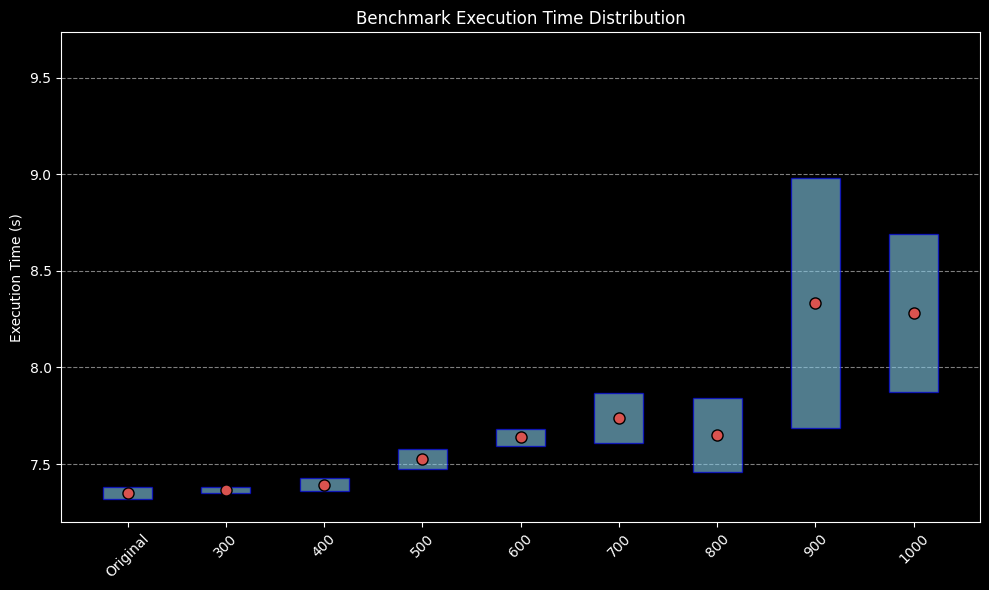

In [22]:
run_size_benchmark(render_original)

## 5.3 Variable Camera Grid Sizes

The following code runs the `render_original` function on datacubes of fixed datacube size but variating the output image size, measuring the execution time for each size. The following parameters are used:

- Datacube size: $600$
- Camera grid size (N): $[100,500]$ with a step of $100$
- Number of viewing angles (Nangles): $10$ (same as the original code)
- Number of runs: $5$

In [3]:
def run_n_benchmark(render_func, Ns=range(100, 550, 100), target_size=600, Nangles=10, num_runs=5):

    baseline_n = 180
    test_queue = [("Original Cube", "datacube/datacube_original.hdf5", baseline_n)]

    # 2. Variable N on target size
    target_path = f"datacube/generated/datacube_{target_size}.hdf5"
    for n in Ns:
        test_queue.append((f"Size {target_size}", target_path, n))

    # Initialize Markdown Table
    md_output = "| Cube Source | Camera Grid (N) | Average Time (s) | Std Dev (s) |\n"
    md_output += "| :--- | :--- | :--- | :--- |\n"

    results = []

    # Run Benchmark
    for label, path, n in test_queue:
        times = []
        error_occurred = False
        print(f"Running benchmark for N={n} ({label})...", end="\r")

        for _ in range(num_runs):
            try:
                start_time = time.time()
                render_func(path, n, Nangles)
                times.append(time.time() - start_time)
            except Exception as e:
                md_output += f"| {label} | {n} | Error: {e} | - |\n"
                error_occurred = True
                break

        if not error_occurred and times:
            avg_time = np.mean(times)
            std_dev = np.std(times)

            # Add Row to Markdown Table
            md_output += f"| {label} | **{n}** | {avg_time:.4f} | {std_dev:.4f} |\n"

            # Collect Data for Chart
            results.append({
                "label": f"N={n}\n({label})",
                "mean": avg_time,
                "std": std_dev,
                "min": np.min(times),
                "max": np.max(times)
            })

    print("Benchmark complete.                               ")

    # Display Table
    display(Markdown(md_output))

    # Display Chart
    if results:
        plt.figure(figsize=(12, 6), dpi=100)

        labels = [r["label"] for r in results]
        x_pos = np.arange(len(labels))

        for i, res in enumerate(results):
            # 1. Whiskers (Min/Max)
            plt.vlines(x_pos[i], res["min"], res["max"], color='black', linewidth=1.5, zorder=1)
            plt.hlines([res["min"], res["max"]], x_pos[i]-0.15, x_pos[i]+0.15, color='black', linewidth=1.5, zorder=1)

            # 2. Box (Std Dev)
            rect_height = 2 * res["std"]
            rect_bottom = res["mean"] - res["std"]
            plt.gca().add_patch(Rectangle(
                (x_pos[i]-0.25, rect_bottom), 0.5, rect_height,
                facecolor='skyblue', alpha=0.6, edgecolor='blue', zorder=2
            ))

            # 3. Mean Dot
            plt.plot(x_pos[i], res["mean"], 'o', color='#D9534F', markeredgecolor='black', markersize=8, zorder=3)

        plt.xticks(x_pos, labels, rotation=0, ha='center', fontsize=9)
        plt.ylabel("Execution Time (s)")
        plt.title(f"Benchmark Results: Variable Camera Grid Size (Target Cube Size: {target_size})")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

Benchmark complete.                               ing benchmark for N=200 (Size 600)...Running benchmark for N=400 (Size 600)...


| Cube Source | Camera Grid (N) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- | :--- |
| Original Cube | **180** | 7.4257 | 0.0301 |
| Size 600 | **100** | 1.6008 | 0.0313 |
| Size 600 | **200** | 10.5382 | 0.5187 |
| Size 600 | **300** | 34.8591 | 0.8238 |
| Size 600 | **400** | 110.7556 | 4.1012 |


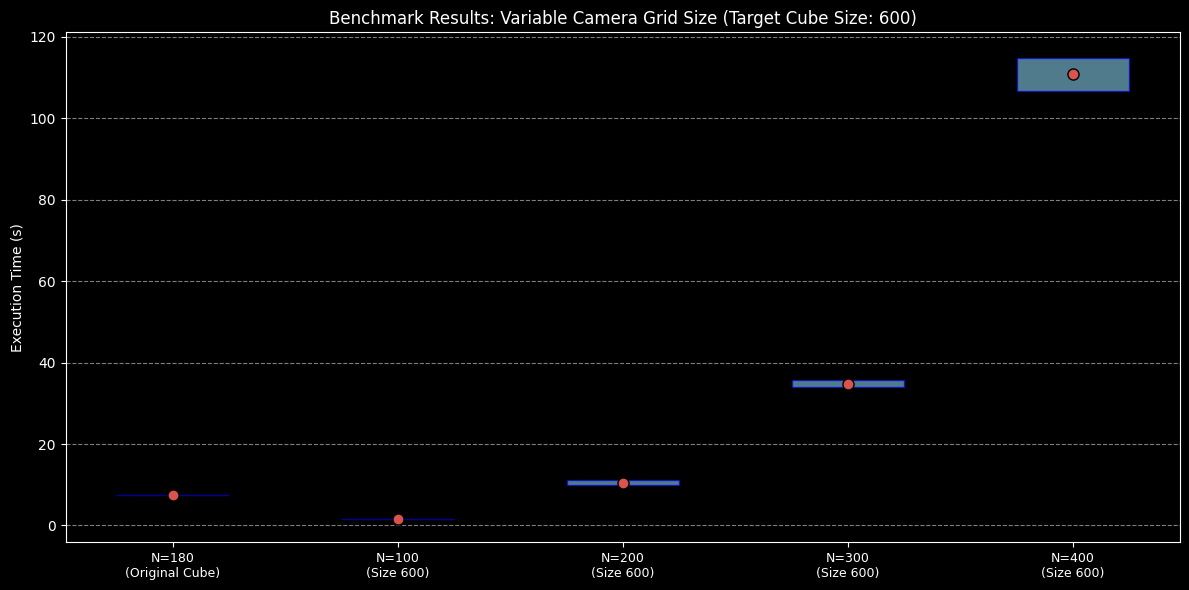

In [20]:
run_n_benchmark(render_original, Ns=range(100, 500, 100))

## 5.4 Variable Camera Angle Counts

- Datacube size: Original hdf5
- Camera grid size (N): $180$
- Number of viewing angles (Nangles): $[5,30]$
- Number of runs: $5$

In [4]:
def run_angles_benchmark(render_func, path="datacube/datacube_original.hdf5", angles_range=range(5, 35, 5), N=180, num_runs=5):
    md_output = "| Camera Angles (Nangles) | Average Time (s) | Std Dev (s) |\n"
    md_output += "| :--- | :--- | :--- |\n"

    results = []

    for n_angle in angles_range:
        print(f"Running benchmark for {n_angle} angles...", end="\r")
        times = []
        error_occurred = False

        for _ in range(num_runs):
            try:
                start_time = time.time()
                render_func(path, N, n_angle)
                times.append(time.time() - start_time)
            except Exception as e:
                md_output += f"| {n_angle} | Error: {e} | - |\n"
                error_occurred = True
                break

        if not error_occurred and times:
            avg_time = np.mean(times)
            std_dev = np.std(times)

            # Add to Markdown Table
            md_output += f"| **{n_angle}** | {avg_time:.4f} | {std_dev:.4f} |\n"

            # Store for Chart
            results.append({
                "label": str(n_angle),
                "mean": avg_time,
                "std": std_dev,
                "min": np.min(times),
                "max": np.max(times)
            })

    print("Benchmark complete.                               ")

    # Display Table
    display(Markdown(md_output))

    # Display Chart
    if results:
        plt.figure(figsize=(10, 6), dpi=100)

        labels = [r["label"] for r in results]
        x_pos = np.arange(len(labels))

        for i, res in enumerate(results):
            # 1. Whiskers (Min/Max)
            plt.vlines(x_pos[i], res["min"], res["max"], color='black', linewidth=1.5, zorder=1)
            plt.hlines([res["min"], res["max"]], x_pos[i]-0.15, x_pos[i]+0.15, color='black', linewidth=1.5, zorder=1)

            # 2. Box (Std Dev)
            rect_height = 2 * res["std"]
            rect_bottom = res["mean"] - res["std"]
            plt.gca().add_patch(Rectangle(
                (x_pos[i]-0.25, rect_bottom), 0.5, rect_height,
                facecolor='skyblue', alpha=0.6, edgecolor='blue', zorder=2
            ))

            # 3. Mean Dot
            plt.plot(x_pos[i], res["mean"], 'o', color='#D9534F', markeredgecolor='black', markersize=8, zorder=3)

        plt.xticks(x_pos, labels)
        plt.xlabel("Number of Angles")
        plt.ylabel("Execution Time (s)")
        plt.title("Benchmark Results: Variable Camera Angles")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

Benchmark complete.                               


| Camera Angles (Nangles) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| **5** | 3.8009 | 0.2560 |
| **10** | 7.4133 | 0.0713 |
| **15** | 11.0125 | 0.0172 |
| **20** | 14.6789 | 0.0111 |
| **25** | 18.3406 | 0.0239 |
| **30** | 21.9904 | 0.0468 |


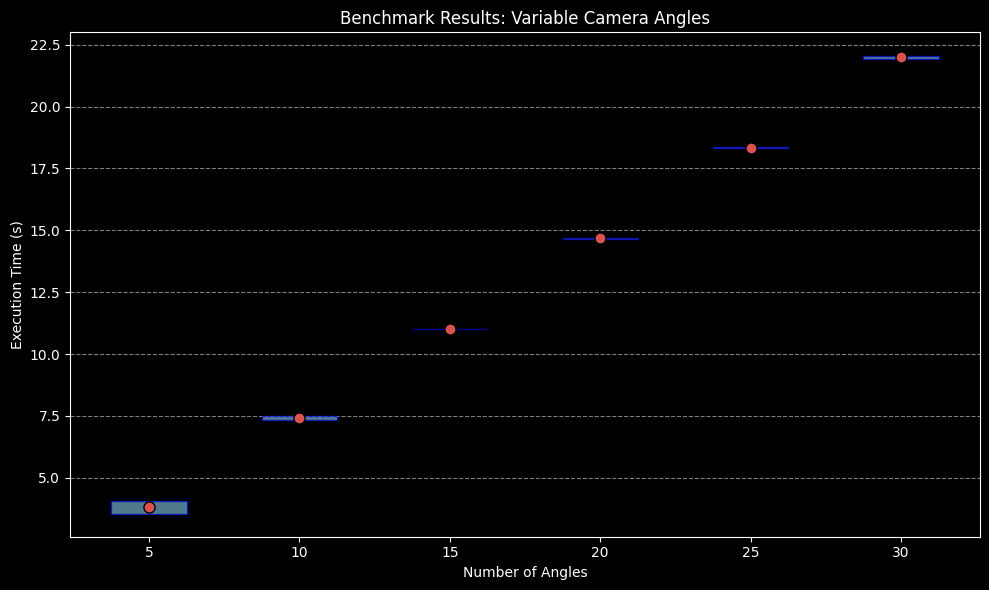

In [21]:
run_angles_benchmark(render_original, num_runs=5)

## 5.5 Orignal Projection Image

In [4]:
render_original("datacube/datacube_original.hdf5", 180, 10)

0

# 6. Optimisations

## 6.1 Optimisation 1: Rewriting mathematical operations with PyTorch to support for GPU calculations

In [5]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as fun
import os

def transfer_torch(x):
    # Converted to torch functions
    r = (
        1.0 * torch.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * torch.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.1 * torch.exp(-((x - -3.0) ** 2) / 0.5)
    )
    g = (
        1.0 * torch.exp(-((x - 9.0) ** 2) / 1.0)
        + 1.0 * torch.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.1 * torch.exp(-((x - -3.0) ** 2) / 0.5)
    )
    b = (
        0.1 * torch.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * torch.exp(-((x - 3.0) ** 2) / 0.1)
        + 1.0 * torch.exp(-((x - -3.0) ** 2) / 0.5)
    )
    a = (
        0.6 * torch.exp(-((x - 9.0) ** 2) / 1.0)
        + 0.1 * torch.exp(-((x - 3.0) ** 2) / 0.1)
        + 0.01 * torch.exp(-((x - -3.0) ** 2) / 0.5)
    )

    return r, g, b, a

def render_torch(path, N, Nangles):

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    os.makedirs("img_out", exist_ok=True)

    with h5.File(path, "r") as f:
        datacube = np.array(f["density"])

    # Prepare tensor for grid_sample: shape (1, 1, Nx, Ny, Nz)
    # grid_sample expects a 5D tensor for 3D volumes (Batch, Channels, Depth, Height, Width)
    volume = torch.tensor(datacube, dtype=torch.float32, device=device)
    volume = volume.unsqueeze(0).unsqueeze(0)

    # Base Camera Grid, normalised [-1, 1] for grid_sample
    # Using 'ij' indexing with swapped outputs to accurately mimic numpy's default 'xy' meshgrid behaviour
    c = torch.linspace(-1, 1, N, device=device)
    qy, qx, qz = torch.meshgrid(c, c, c, indexing='ij')

    for i in range(Nangles):
        angle = np.pi / 2 * i / Nangles

        qxR = qx
        qyR = qy * np.cos(angle) - qz * np.sin(angle)
        qzR = qy * np.sin(angle) + qz * np.cos(angle)

        # interpolation, grid_sample expects coordinates in (w, h, d) order corresponding to (z, y, x) spatial dimensions
        grid = torch.stack((qzR, qyR, qxR), dim=-1).unsqueeze(0)

        camera_grid = fun.grid_sample(
            volume,
            grid,
            mode="bilinear",
            padding_mode="zeros",
            align_corners=True
        )

        # Squeeze batch and channel dims -> shape (N, N, N)
        camera_grid = camera_grid.squeeze(0).squeeze(0)

        # Pre-calculate logs for the entire grid to avoid recalculating in the loop
        log_grid = torch.log(camera_grid.clamp(min=1e-10))

        # Do Volume Rendering (Alpha Compositing)
        image = torch.zeros((N, N, 3), device=device)

        # We iterate over the first dimension (depth slices)
        for j in range(N):
            dataslice = log_grid[j]
            r, g, b, a = transfer_torch(dataslice)

            image[:, :, 0] = a * r + (1 - a) * image[:, :, 0]
            image[:, :, 1] = a * g + (1 - a) * image[:, :, 1]
            image[:, :, 2] = a * b + (1 - a) * image[:, :, 2]

        image = torch.clamp(image, 0.0, 1.0).cpu().numpy()

        # Plot & Save Volume Rendering
        plt.figure(figsize=(4, 4), dpi=80)
        plt.imshow(image)
        plt.axis("off")
        plt.savefig(
            f"img_out/volumerender{i}.png", dpi=240, bbox_inches="tight", pad_inches=0
        )
        plt.close('all')

    # Plot Simple Projection -- for Comparison
    plt.figure(figsize=(4, 4), dpi=80)
    plt.imshow(np.log(np.mean(datacube, 0)), cmap="viridis")
    plt.clim(-5, 5)
    plt.axis("off")
    plt.savefig("img_out/projection.png", dpi=240, bbox_inches="tight", pad_inches=0)
    plt.close('all')

### Benchmarking

#### Variable Datacube Grid Size

Benchmark complete.                               k for: 400...Running benchmark for: 600...Running benchmark for: 800...Running benchmark for: 1000...


| Datacube Size | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| Original | 1.3908 | 0.8836 |
| 300 | 0.9995 | 0.0498 |
| 400 | 1.0443 | 0.0180 |
| 500 | 1.5662 | 0.9645 |
| 600 | 1.2881 | 0.3456 |
| 700 | 1.6996 | 0.8008 |
| 800 | 1.5500 | 0.4118 |
| 900 | 2.1257 | 1.0942 |
| 1000 | 5.6876 | 6.4414 |


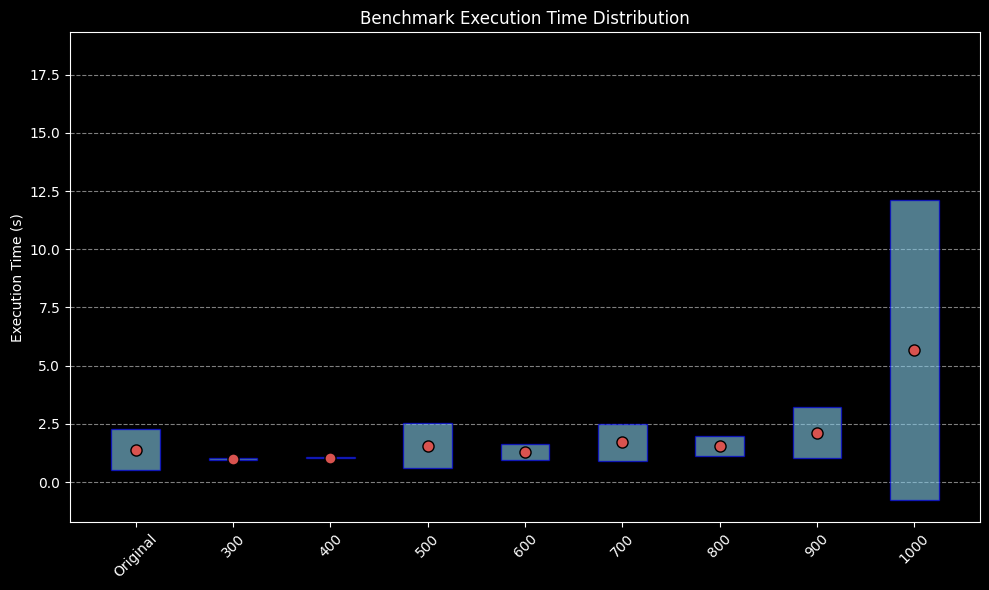

In [10]:
run_size_benchmark(render_torch)

#### Variable Camera Grid Size

)...Running benchmark for N=200 (Size 600)...Running benchmark for N=400 (Size 600)...Benchmark complete.                               


| Cube Source | Camera Grid (N) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- | :--- |
| Original Cube | **180** | 0.9167 | 0.0265 |
| Size 600 | **100** | 1.2621 | 1.2402 |
| Size 600 | **200** | 1.2728 | 0.0204 |
| Size 600 | **300** | 3.4994 | 0.8100 |
| Size 600 | **400** | 9.7609 | 6.6061 |
| Size 600 | **500** | 11.9701 | 1.2773 |


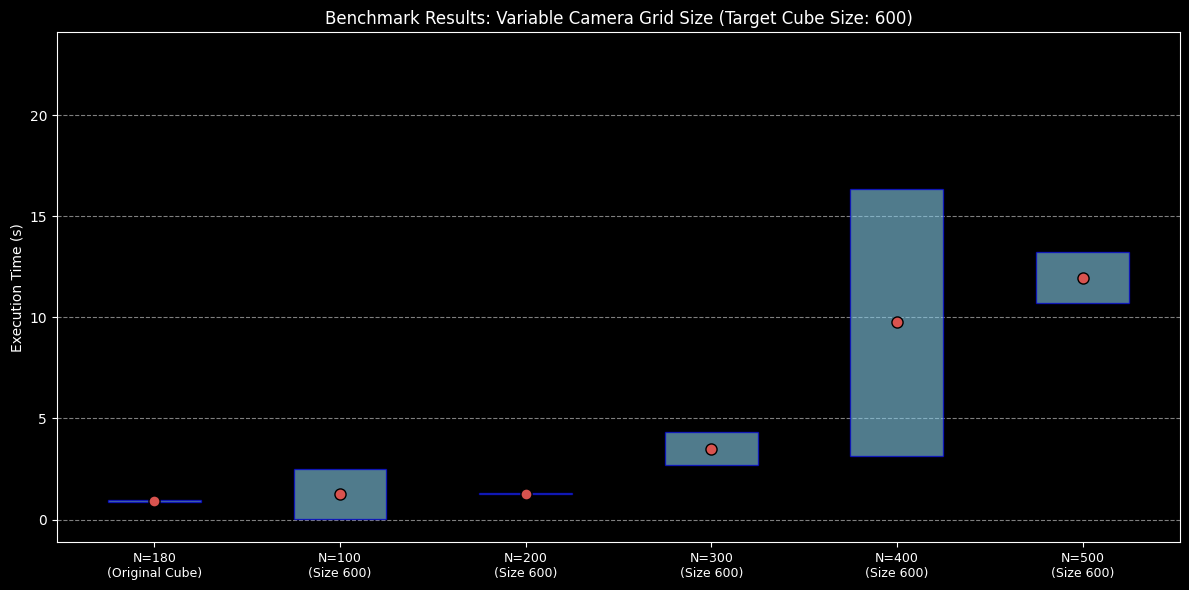

In [12]:
run_n_benchmark(render_torch)

#### Variable Camera Angles

Benchmark complete.                               


| Camera Angles (Nangles) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| **5** | 0.5050 | 0.0593 |
| **10** | 0.9318 | 0.0176 |
| **15** | 1.3767 | 0.0487 |
| **20** | 1.7658 | 0.0535 |
| **25** | 2.9946 | 0.4794 |
| **30** | 4.1469 | 0.1248 |


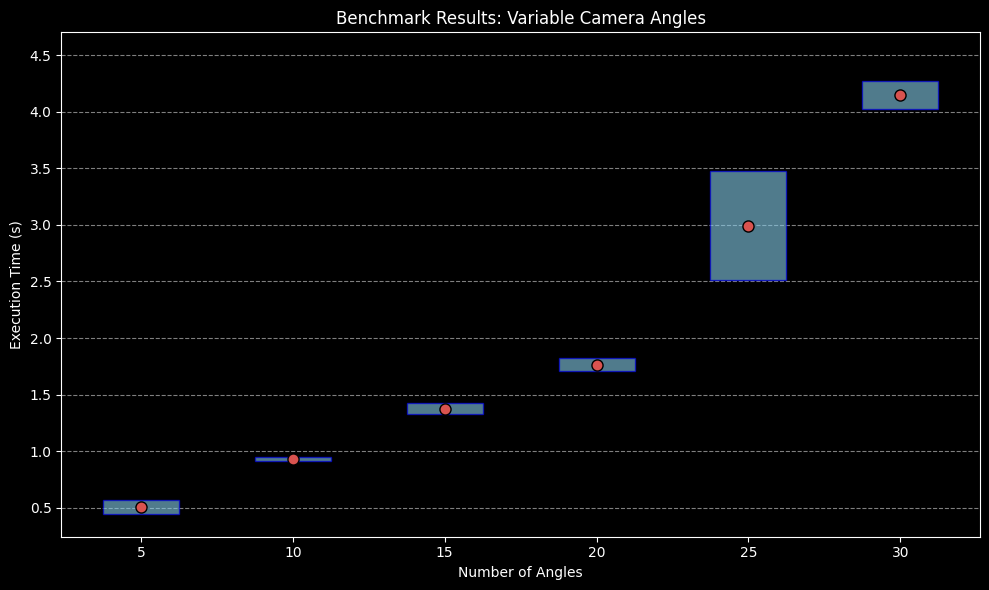

In [11]:
run_angles_benchmark(render_torch, num_runs=10)

### Validation Test

In [6]:
render_torch("datacube/datacube_original.hdf5", 180, 10)

## 6.2 Optimisation 2: Parallelising angles rendering with Dask Delayed

In [8]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(processes=True, threads_per_worker=1)
client = Client(cluster)

In [13]:
client.close()
cluster.close()

In [7]:
from scipy.interpolate import interpn
import os
import h5py as h5
import numpy as np
import dask
import matplotlib.pyplot as plt
import matplotlib
from dask import delayed

def transfer_function_dask(x):
    r = (
            1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    g = (
            1.0 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 1.0 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 0.1 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    b = (
            0.1 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 1.0 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )
    a = (
            0.6 * np.exp(-((x - 9.0) ** 2) / 1.0)
            + 0.1 * np.exp(-((x - 3.0) ** 2) / 0.1)
            + 0.01 * np.exp(-((x - -3.0) ** 2) / 0.5)
    )

    return r, g, b, a

@delayed
def render_angle_dask(i, Nangles, N, points, datacube):
    angle = np.pi / 2 * i / Nangles
    c = np.linspace(-N / 2, N / 2, N)

    # Pre-allocate the final 2D image (N x N x 3)
    image = np.zeros((N, N, 3))

    # We iterate through the depth axis, calculating and discarding one slice at a time.
    for depth_idx in range(N):
        qz_val = c[depth_idx]

        qx, qy = np.meshgrid(c, c)

        qxR = qx
        qyR = qy * np.cos(angle) - qz_val * np.sin(angle)
        qzR = qy * np.sin(angle) + qz_val * np.cos(angle)

        qi_slice = np.array([qxR.ravel(), qyR.ravel(), qzR.ravel()]).T

        dataslice = interpn(points, datacube, qi_slice, method="linear", bounds_error=False, fill_value=0).reshape((N, N))

        with np.errstate(divide='ignore', invalid='ignore'):
            log_slice = np.log(dataslice)

        r, g, b, a = transfer_function_dask(log_slice)

        image[:, :, 0] = a * r + (1 - a) * image[:, :, 0]
        image[:, :, 1] = a * g + (1 - a) * image[:, :, 1]
        image[:, :, 2] = a * b + (1 - a) * image[:, :, 2]

    image = np.clip(image, 0.0, 1.0)

    fig = plt.figure(figsize=(4, 4), dpi=80)
    plt.imshow(image)
    plt.axis("off")
    plt.savefig(f"img_out/volumerender{i}.png", dpi=240, bbox_inches="tight", pad_inches=0)
    plt.clf()
    plt.close(fig)

    return i

def render_dask(path, N, Nangles):
    os.makedirs("img_out", exist_ok=True)

    with h5.File(path, "r") as f:
        datacube = np.array(f["density"])

    Nx, Ny, Nz = datacube.shape
    x = np.linspace(-Nx / 2, Nx / 2, Nx)
    y = np.linspace(-Ny / 2, Ny / 2, Ny)
    z = np.linspace(-Nz / 2, Nz / 2, Nz)
    points = (x, y, z)

    # Send data to workers once, returning a Future pointer
    datacube_future = client.scatter(datacube, broadcast=True)

    tasks = []
    for i in range(Nangles):
        # Pass the Future, NOT the raw numpy array
        task = render_angle_dask(i, Nangles, N, points, datacube_future)
        tasks.append(task)

    dask.compute(*tasks)

    fig = plt.figure(figsize=(4, 4), dpi=80)
    with np.errstate(divide='ignore', invalid='ignore'):
        plt.imshow(np.log(np.mean(datacube, 0)), cmap="viridis")
    plt.clim(-5, 5)
    plt.axis("off")
    plt.savefig("img_out/projection.png", dpi=240, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

### Benchmarking

#### Variable Datacube Grid Size

Benchmark complete.                               k for: 400...Running benchmark for: 600...


| Datacube Size | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| Original | 3.8753 | 0.4234 |
| 300 | 3.0421 | 0.0154 |
| 400 | 2.9645 | 0.0229 |
| 500 | 3.4037 | 0.0959 |
| 600 | 5.2997 | 1.5668 |


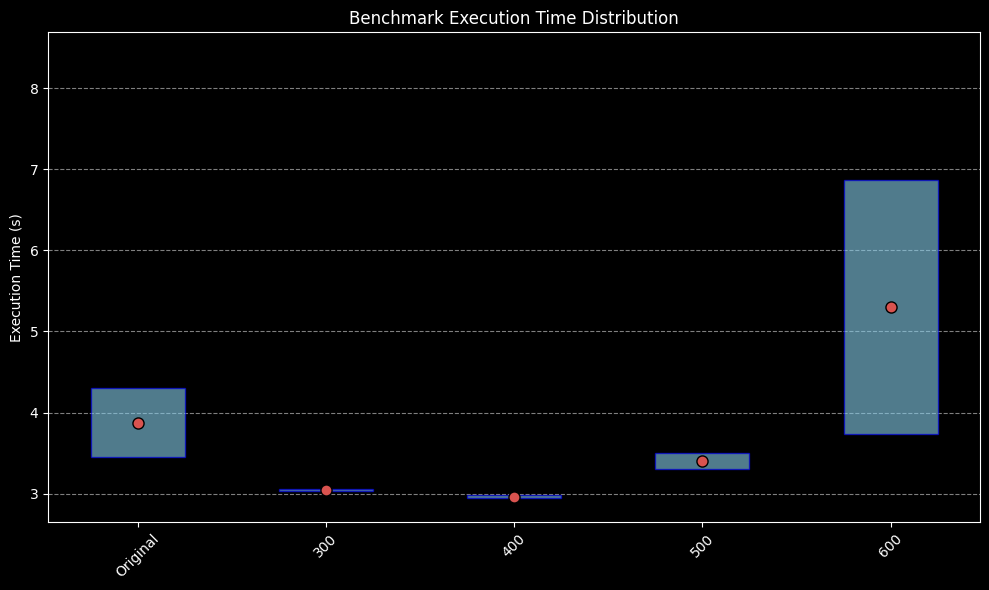

In [7]:
    run_size_benchmark(render_dask, range(300,700,100))

#### Variable Camera Grid Size

)...Running benchmark for N=200 (Size 600)...Running benchmark for N=400 (Size 600)...

2026-03-12 09:38:54,794 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:59858 -> tcp://127.0.0.1:59846
Traceback (most recent call last):
  File "/Users/anson/Documents/project/.venv/lib/python3.14/site-packages/tornado/iostream.py", line 962, in _handle_write
    num_bytes = self.write_to_fd(self._write_buffer.peek(size))
  File "/Users/anson/Documents/project/.venv/lib/python3.14/site-packages/tornado/iostream.py", line 1121, in write_to_fd
    return self.socket.send(data)  # type: ignore
           ~~~~~~~~~~~~~~~~^^^^^^
OSError: [Errno 55] No buffer space available

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/anson/Documents/project/.venv/lib/python3.14/site-packages/distributed/worker.py", line 1803, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/anson/Documents/project/.venv/lib/pyth

Benchmark complete.                               


| Cube Source | Camera Grid (N) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- | :--- |
| Original Cube | **180** | 3.6244 | 0.5886 |
| Size 600 | **100** | 2.3803 | 0.7126 |
| Size 600 | **200** | 6.2433 | 0.7794 |
| Size 600 | **300** | 27.4269 | 2.9153 |
| Size 600 | **400** | 59.8244 | 1.8765 |
| Size 600 | **500** | 118.0199 | 3.8696 |


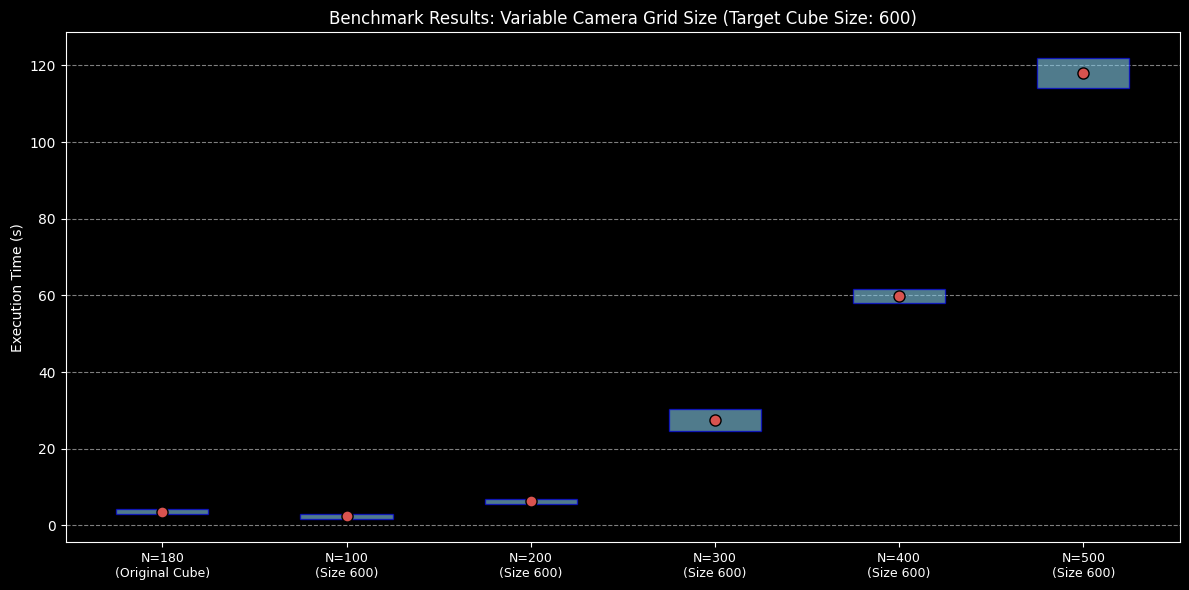

In [8]:
run_n_benchmark(render_dask, target_size=600)

#### Variable Camera Angles

Benchmark complete.                               


| Camera Angles (Nangles) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| **5** | 1.9827 | 0.0554 |
| **10** | 3.0875 | 0.0349 |
| **15** | 4.7476 | 0.1119 |
| **20** | 6.0158 | 0.0724 |
| **25** | 8.1679 | 0.2737 |
| **30** | 13.1673 | 1.4959 |


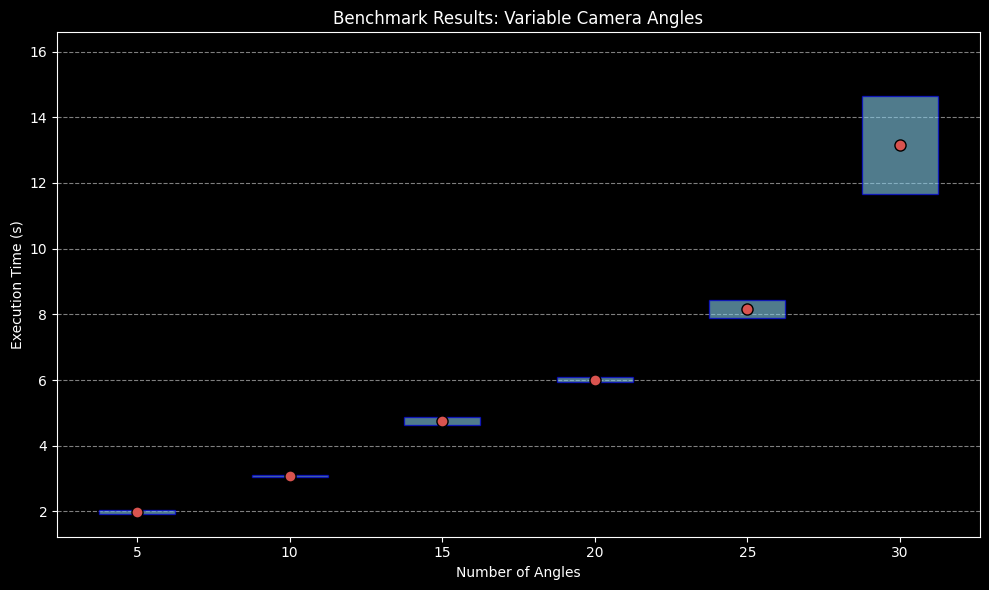

In [9]:
run_angles_benchmark(render_dask, num_runs=5)

### Validation Test

In [ ]:
render_dask("datacube/datacube_original.hdf5", 180, 10)

## 6.3 Optimisation 3: Optimise with precomiled code with Cython

### Annotated Cython Code

In [20]:
%%file renderer_cython_fun.pyx
# cython: language_level=3
# cython: boundscheck=False
# cython: wraparound=False
# cython: cdivision=True

import numpy as np
cimport numpy as cnp
from libc.math cimport exp, log, cos, sin, floor

cdef (double, double, double, double) transfer_function_cython(double x) nogil:
    cdef double r, g, b, a
    r = (1.0 * exp(-((x - 9.0)**2) / 1.0) + 0.1 * exp(-((x - 3.0)**2) / 0.1) + 0.1 * exp(-((x + 3.0)**2) / 0.5))
    g = (1.0 * exp(-((x - 9.0)**2) / 1.0) + 1.0 * exp(-((x - 3.0)**2) / 0.1) + 0.1 * exp(-((x + 3.0)**2) / 0.5))
    b = (0.1 * exp(-((x - 9.0)**2) / 1.0) + 0.1 * exp(-((x - 3.0)**2) / 0.1) + 1.0 * exp(-((x + 3.0)**2) / 0.5))
    a = (0.6 * exp(-((x - 9.0)**2) / 1.0) + 0.1 * exp(-((x - 3.0)**2) / 0.1) + 0.01 * exp(-((x + 3.0)**2) / 0.5))
    return r, g, b, a

cdef double trilinear_interp_cython(double[:, :, :] data, double x, double y, double z) nogil:
    cdef int x0 = <int>floor(x)
    cdef int y0 = <int>floor(y)
    cdef int z0 = <int>floor(z)
    cdef int x1 = x0 + 1
    cdef int y1 = y0 + 1
    cdef int z1 = z0 + 1

    # Bounds check for the interpolation box
    if x0 < 0 or x1 >= data.shape[0] or y0 < 0 or y1 >= data.shape[1] or z0 < 0 or z1 >= data.shape[2]:
        return 0.0

    cdef double xd = x - x0
    cdef double yd = y - y0
    cdef double zd = z - z0

    cdef double c00 = data[x0, y0, z0] * (1 - xd) + data[x1, y0, z0] * xd
    cdef double c01 = data[x0, y0, z1] * (1 - xd) + data[x1, y0, z1] * xd
    cdef double c10 = data[x0, y1, z0] * (1 - xd) + data[x1, y1, z0] * xd
    cdef double c11 = data[x0, y1, z1] * (1 - xd) + data[x1, y1, z1] * xd

    cdef double c0 = c00 * (1 - yd) + c10 * yd
    cdef double c1 = c01 * (1 - yd) + c11 * yd

    return c0 * (1 - zd) + c1 * zd

def render_angle_cython(double[:, :, :] datacube, int N, double angle):
    cdef int Nx = datacube.shape[0]
    cdef int Ny = datacube.shape[1]
    cdef int Nz = datacube.shape[2]

    cdef double[:, :, :] image = np.zeros((N, N, 3), dtype=np.float64)
    cdef double r, g, b, a, val
    cdef double qx, qy, qz, qyR, qzR
    cdef double ix, iy, iz
    cdef int i, j, k

    # Scaling factors to map camera space to datacube index space
    cdef double center_N = N / 2.0
    cdef double center_x = Nx / 2.0
    cdef double center_y = Ny / 2.0
    cdef double center_z = Nz / 2.0

    for i in range(N):      # Depth (front to back)
        for j in range(N):  # Vertical
            for k in range(N): # Horizontal
                # Map camera grid to coordinates
                qx = k - center_N
                qy = j - center_N
                qz = i - center_N

                # Rotate coordinates
                qyR = qy * cos(angle) - qz * sin(angle)
                qzR = qy * sin(angle) + qz * cos(angle)

                # Convert to array indices
                ix = qx + center_x
                iy = qyR + center_y
                iz = qzR + center_z

                # Trilinear Interpolation
                val = trilinear_interp_cython(datacube, ix, iy, iz)

                if val <= 1e-10:
                    continue

                # Blend Volume
                r, g, b, a = transfer_function_cython(log(val))
                image[j, k, 0] = a * r + (1.0 - a) * image[j, k, 0]
                image[j, k, 1] = a * g + (1.0 - a) * image[j, k, 1]
                image[j, k, 2] = a * b + (1.0 - a) * image[j, k, 2]

    return np.asarray(image).clip(0.0, 1.0)

Writing renderer_cython_fun.pyx


### Setup Script

In [32]:
%%file renderer_cython_setup.py
from setuptools import setup, Extension
from Cython.Build import cythonize
import numpy
import os

numpy_include = numpy.get_include()
print(f"Checking NumPy include path: {numpy_include}")

if not os.path.exists(os.path.join(numpy_include, 'numpy', 'arrayobject.h')):
    print("WARNING: Could not find arrayobject.h in the include path!")

ext = Extension(
    "renderer_cython_fun",
    sources=["renderer_cython_fun.pyx"],
    include_dirs=[numpy_include],
    define_macros=[("NPY_NO_DEPRECATED_API", "NPY_1_7_API_VERSION")]
)

setup(
    name="CythonRenderer",
    ext_modules=cythonize(ext, annotate=True),
    packages=[],
)

Overwriting renderer_cython_setup.py


In [ ]:
!python renderer_cython_setup.py build_ext --inplace

### Python Interface

In [10]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import os
from renderer_cython_fun import render_angle_cython

def render_cython(path, N, Nangles):
    """High-performance Cython entry point."""
    os.makedirs("img_out", exist_ok=True)

    with h5.File(path, "r") as f:
        datacube = np.array(f["density"], dtype=np.float64)

    for i in range(Nangles):
        angle = np.pi / 2 * i / Nangles

        image = render_angle_cython(datacube, N, angle)

        plt.figure(figsize=(4, 4), dpi=80)
        plt.imshow(image)
        plt.axis("off")
        plt.savefig(f"img_out/volumerender{i}.png", dpi=240, bbox_inches="tight", pad_inches=0)
        plt.close()

    # Projection for comparison
    plt.figure(figsize=(4, 4), dpi=80)
    plt.imshow(np.log(np.mean(datacube, 0)), cmap="viridis")
    plt.clim(-5, 5)
    plt.axis("off")
    plt.savefig("img_out/projection.png", dpi=240, bbox_inches="tight", pad_inches=0)
    plt.close()

### Benchmarking

#### Variable Datacube Grid Size

Benchmark complete.                               k for: 400...Running benchmark for: 600...Running benchmark for: 800...Running benchmark for: 1000...


| Datacube Size | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| Original | 1.6679 | 0.0875 |
| 300 | 1.2615 | 0.0426 |
| 400 | 1.3460 | 0.0767 |
| 500 | 1.4028 | 0.1376 |
| 600 | 1.5478 | 0.2538 |
| 700 | 1.7504 | 0.4334 |
| 800 | 2.1943 | 0.8402 |
| 900 | 2.7995 | 0.9112 |
| 1000 | 2.8868 | 0.6680 |


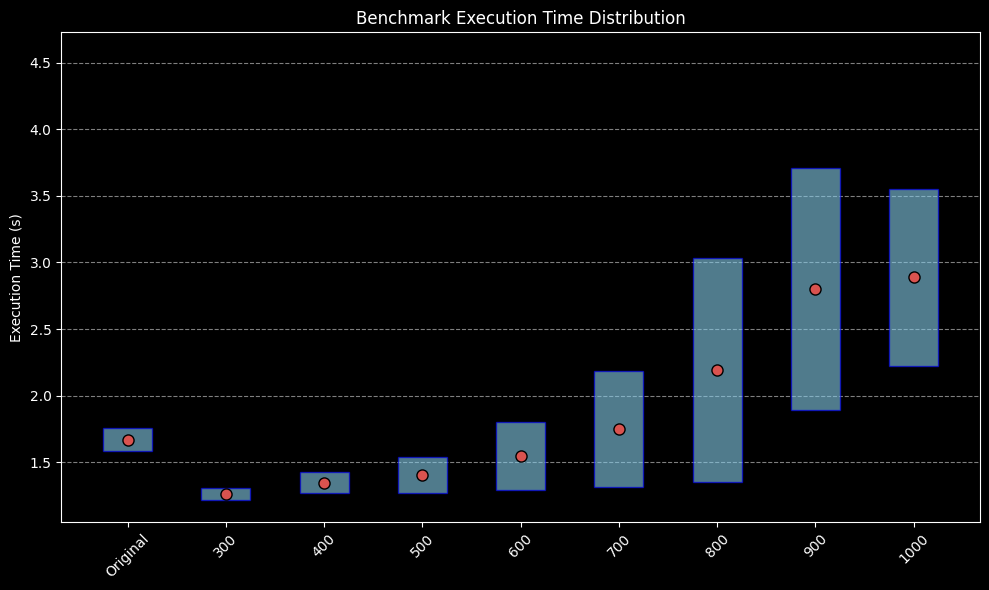

In [14]:
run_size_benchmark(render_cython)

#### Variable Camera Grid Size

)...Running benchmark for N=200 (Size 600)...Running benchmark for N=400 (Size 600)...Benchmark complete.                               


| Cube Source | Camera Grid (N) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- | :--- |
| Original Cube | **180** | 1.7039 | 0.0717 |
| Size 600 | **100** | 0.5965 | 0.0930 |
| Size 600 | **200** | 1.8477 | 0.0091 |
| Size 600 | **300** | 6.3142 | 0.0583 |
| Size 600 | **400** | 18.7056 | 0.1586 |
| Size 600 | **500** | 45.8751 | 0.3226 |


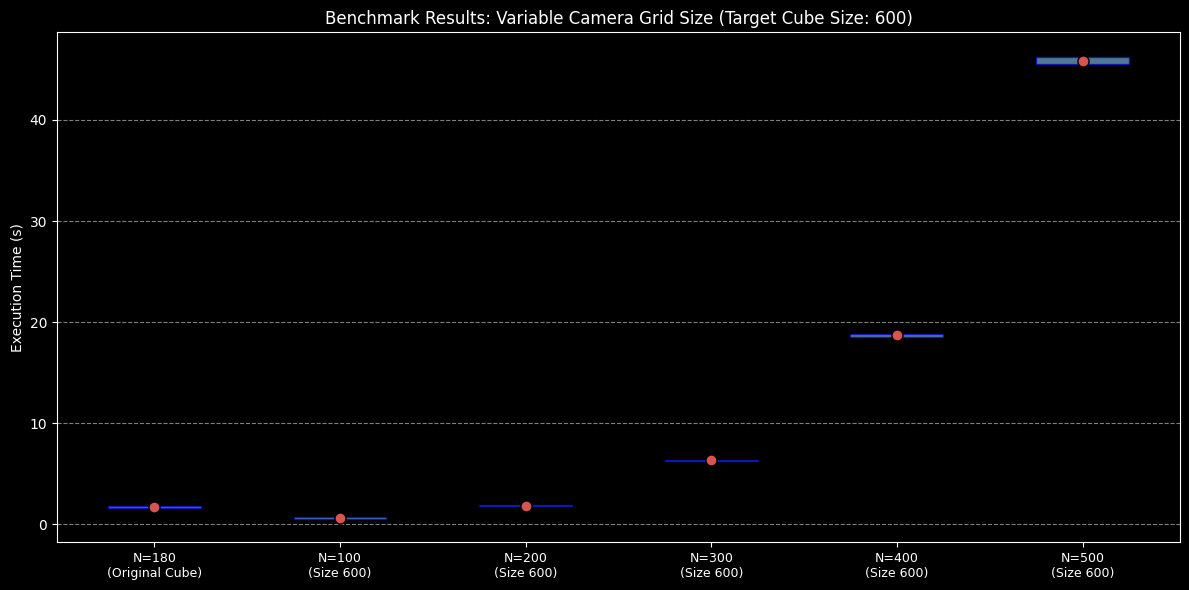

In [15]:
run_n_benchmark(render_cython)

#### Variable Camera Angles

Benchmark complete.                               


| Camera Angles (Nangles) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| **5** | 0.8842 | 0.0269 |
| **10** | 1.8556 | 0.1965 |
| **15** | 2.8465 | 0.7834 |
| **20** | 3.4850 | 0.4775 |
| **25** | 4.2073 | 0.4894 |
| **30** | 5.2151 | 0.4977 |


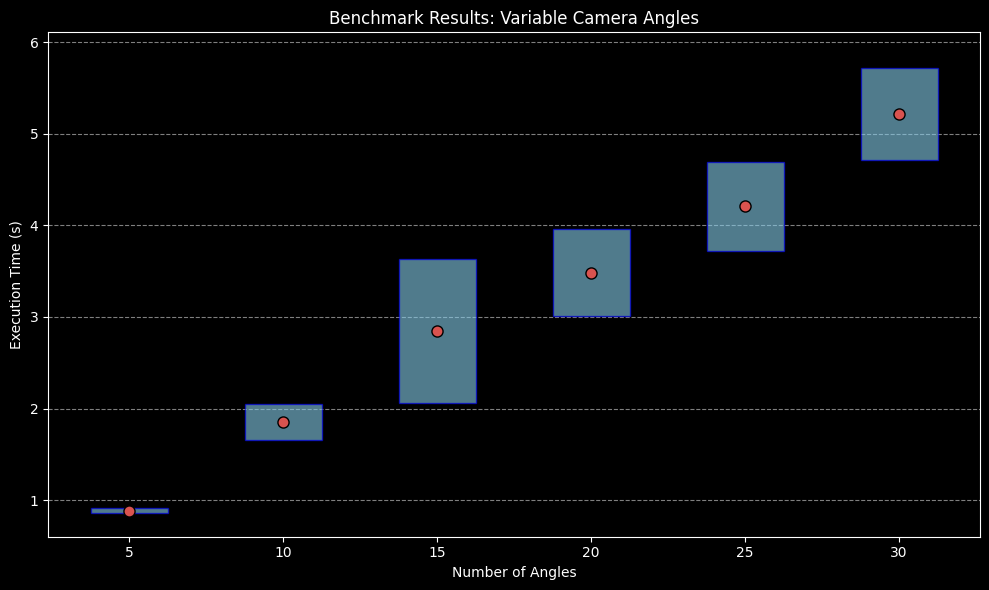

In [16]:
run_angles_benchmark(render_cython, num_runs=5)

### Validation Test

In [11]:
render_cython("datacube/datacube_original.hdf5", 180, 10)

# 7. Accumulated Optimisation with Multiple Techniques

In [12]:
import h5py as h5
import numpy as np
import torch
import torch.nn.functional as fun
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

def transfer_function_ultimate(x):
    x_minus_9_sq = (x - 9.0) ** 2
    x_minus_3_sq = (x - 3.0) ** 2
    x_plus_3_sq  = (x + 3.0) ** 2

    r = 1.0 * torch.exp(-x_minus_9_sq / 1.0) + 0.1 * torch.exp(-x_minus_3_sq / 0.1) + 0.1 * torch.exp(-x_plus_3_sq / 0.5)
    g = 1.0 * torch.exp(-x_minus_9_sq / 1.0) + 1.0 * torch.exp(-x_minus_3_sq / 0.1) + 0.1 * torch.exp(-x_plus_3_sq / 0.5)
    b = 0.1 * torch.exp(-x_minus_9_sq / 1.0) + 0.1 * torch.exp(-x_minus_3_sq / 0.1) + 1.0 * torch.exp(-x_plus_3_sq / 0.5)
    a = 0.6 * torch.exp(-x_minus_9_sq / 1.0) + 0.1 * torch.exp(-x_minus_3_sq / 0.1) + 0.01 * torch.exp(-x_plus_3_sq / 0.5)

    return r, g, b, a

def save_image_worker_ultimate(args):
    img_array, index = args
    mpimg.imsave(f"img_out/volumerender{index}.png", img_array)

def render_ultimate(path, N, Nangles):
    os.makedirs("img_out", exist_ok=True)

    if not torch.backends.mps.is_available():
        raise RuntimeError("MPS is not available! Ensure you are running on an Apple Silicon Mac with PyTorch natively installed.")
    device = torch.device("mps")

    with h5.File(path, "r") as f:
        datacube = np.array(f["density"])

    volume = torch.tensor(datacube, dtype=torch.float32, device=device)
    volume = volume.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, Nx, Ny, Nz)

    # Dynamic Memory Batching (Crucial for Mac Unified Memory)
    bytes_per_voxel = 4 # float32
    memory_per_angle = (N ** 3) * bytes_per_voxel * 3 # 3 channels roughly
    safe_ram_limit = 16 * (1024 ** 3) # 18 GB limit per batch

    batch_size = max(1, safe_ram_limit // memory_per_angle)
    # Make sure we don't have a batch size larger than our total angles
    batch_size = min(batch_size, Nangles)

    # Base Camera Grid
    c = torch.linspace(-1, 1, N, device=device)
    qy, qx, qz = torch.meshgrid(c, c, c, indexing='ij')

    # Process in safe batches
    rendered_images_cpu = []

    for start_idx in range(0, Nangles, batch_size):
        end_idx = min(start_idx + batch_size, Nangles)
        current_batch_size = end_idx - start_idx

        # Generate exactly the angles needed for this batch
        indices = torch.arange(start_idx, end_idx, device=device)
        angles = (np.pi / 2 * indices / Nangles).view(-1, 1, 1, 1)

        # Broadcast rotations across the batch
        qyR = qy.unsqueeze(0) * torch.cos(angles) - qz.unsqueeze(0) * torch.sin(angles)
        qzR = qy.unsqueeze(0) * torch.sin(angles) + qz.unsqueeze(0) * torch.cos(angles)
        qxR = qx.unsqueeze(0).expand(current_batch_size, -1, -1, -1)

        # Stack into grid shape: (Batch, N, N, N, 3)
        grid = torch.stack((qzR, qyR, qxR), dim=-1)

        # Expand the volume to match the batch size
        volume_batched = volume.expand(current_batch_size, -1, -1, -1, -1)

        # Massive parallel interpolation on the Metal GPU
        camera_grid = fun.grid_sample(
            volume_batched,
            grid,
            mode="bilinear",
            padding_mode="zeros",
            align_corners=True
        ).squeeze(1) # Remove channel dim -> (Batch, N, N, N)

        # Calculate logs for the whole batch
        log_grid = torch.log(camera_grid.clamp(min=1e-10))

        # Alpha Compositing Loop (Running vectorized on MPS)
        image = torch.zeros((current_batch_size, N, N, 3), device=device)

        for j in range(N):
            dataslice = log_grid[:, j, :, :] # Sliced across depth for all angles
            r, g, b, a = transfer_function_ultimate(dataslice)

            image[..., 0] = a * r + (1 - a) * image[..., 0]
            image[..., 1] = a * g + (1 - a) * image[..., 1]
            image[..., 2] = a * b + (1 - a) * image[..., 2]

        image = torch.clamp(image, 0.0, 1.0)

        # Move this finalized batch back to CPU RAM immediately to free up GPU memory
        rendered_images_cpu.append(image.cpu().numpy())

    # Flatten the list of batches into a single array
    final_images = np.concatenate(rendered_images_cpu, axis=0)

    # Asynchronous Multi-threaded I/O
    print("GPU math complete. Dispatching save tasks to CPU threads...")
    save_tasks = [(final_images[i], i) for i in range(Nangles)]

    with ThreadPoolExecutor() as executor:
        executor.map(save_image_worker_ultimate, save_tasks)

    plt.imsave("img_out/projection.png", np.log(np.mean(datacube, 0)), cmap="viridis", vmin=-5, vmax=5)

### Benchmarking

#### Variable Datacube Grid Size

GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save task

| Datacube Size | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| Original | 0.6665 | 0.2755 |
| 300 | 0.5583 | 0.0080 |
| 400 | 0.6440 | 0.0394 |
| 500 | 0.7723 | 0.1277 |
| 600 | 0.8556 | 0.1828 |
| 700 | 1.0461 | 0.2680 |
| 800 | 1.7143 | 0.8572 |
| 900 | 2.0871 | 1.1646 |
| 1000 | 5.3564 | 1.1884 |


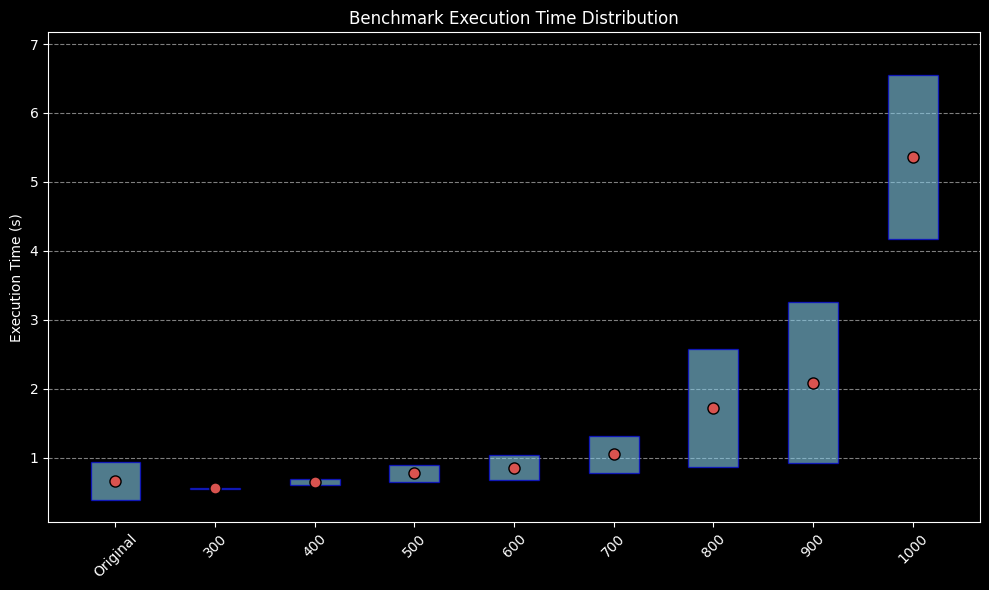

In [7]:
run_size_benchmark(render_ultimate)

#### Variable Camera Grid Size

In [ ]:
run_n_benchmark(render_ultimate)

#### Variable Camera Angles

GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save tasks to CPU threads...
GPU math complete. Dispatching save task

| Camera Angles (Nangles) | Average Time (s) | Std Dev (s) |
| :--- | :--- | :--- |
| **5** | 0.2910 | 0.1074 |
| **10** | 0.5183 | 0.0177 |
| **15** | 0.8498 | 0.0398 |
| **20** | 1.1773 | 0.0516 |
| **25** | 1.6059 | 0.1944 |
| **30** | 2.0863 | 0.3470 |


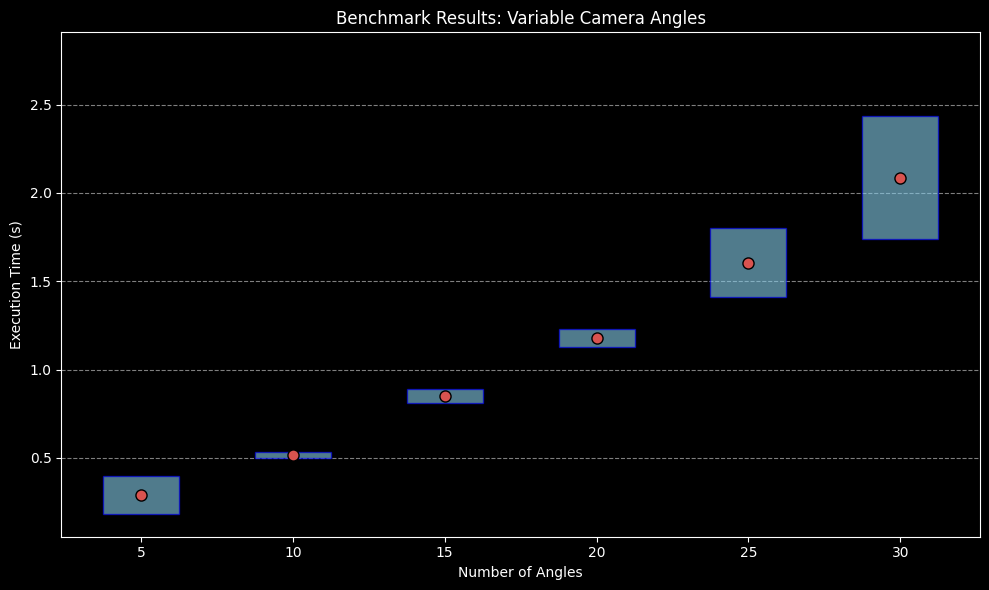

In [9]:
run_angles_benchmark(render_ultimate, num_runs=5)

## Validation Test

In [14]:
render_ultimate("datacube/datacube_original.hdf5", 180, 10)

GPU math complete. Dispatching save tasks to CPU threads...
